In [1]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


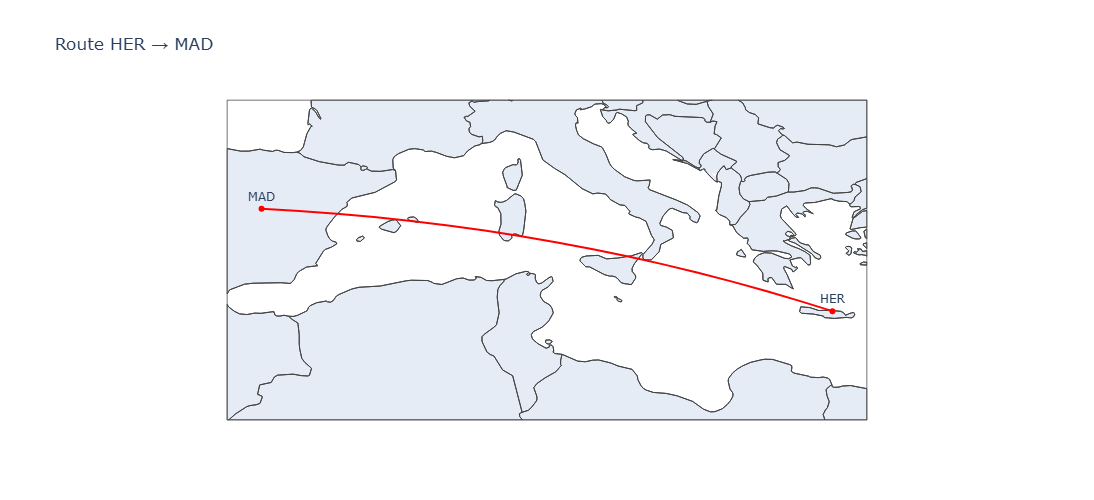

In [3]:
import requests
import plotly.graph_objects as go

API_KEY = "Sd33yrf4kWCq1atCFxzGtZ8qJ5x2oI08zdZ6BASz"

def get_airport(iata):
    url = "https://api.api-ninjas.com/v1/airports"
    response = requests.get(url, params={"iata": iata}, headers={"X-Api-Key": API_KEY})
    response.raise_for_status()      # raises an error if something fails (bad key, etc.)
    return response.json()[0]        # the API returns a list; we take the first item

origin_code = "HER"
destination_code = "MAD"

origin = get_airport(origin_code)
destination = get_airport(destination_code)

fig = go.Figure(go.Scattergeo(
    lon=[float(origin["longitude"]), float(destination["longitude"])],
    lat=[float(origin["latitude"]), float(destination["latitude"])],
    mode="lines+markers+text",
    text=[origin_code, destination_code],
    textposition="top center",
    line=dict(width=2, color="red")
))

fig.update_geos(
    fitbounds="locations",   # automatically zoom to the points
    showcountries=True,      # draw country borders
    resolution=50            # more coastline detail
)
fig.update_layout(
    title=f"Route {origin_code} → {destination_code}",
    height=500
)
fig.show()